# A007 temperature logger Loch Etive 2026-06-01

## Step 1: Import packages for use in Python code and define some functions to use

In [107]:
#Programes and functions
import pandas as pd
import numpy as np
import contextily as ctx
import geopandas as gpd
import datetime
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.ticker as mticker
#import cmocean
from datetime import datetime
from matplotlib import pyplot as plt 
from geopy.distance import geodesic
from pyproj import Transformer
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter

# Function to format tick labels with two decimal places
def format_ticks(value, _):
    return f'{value:.3f}'  # Adjust decimal places here (e.g., .2f for two decimal places)

# Function to convert Web Mercator coordinates to latitude/longitude
def merc_to_lonlat(x, pos):
    lon, lat = transformer_to_lonlat.transform(x, 0)  # Only convert X (Longitude)
    return f"{lon:.3f}°"
def merc_to_latlon(y, pos):
    lon, lat = transformer_to_lonlat.transform(0, y)  # Only convert Y (Latitude)
    return f"{lat:.3f}°"

# Function to compute distances
def haversine_distance(lat1, lon1, lat2, lon2):
    # Returns distance in meters
    return geodesic((lat1, lon1), (lat2, lon2)).meters
def haversine_distance(row):
    if pd.notnull(row['Lat_prev']) and pd.notnull(row['Lon_prev']):
        return geodesic(
            (row['Lat_prev'], row['Lon_prev']),
            (row[' Latitude (degs N)'], row[' Longitude (degs E)'])
        ).meters
    else:
        return 0
    
# Function for map 
def make_column_names_unique(columns):
    seen = {}
    new_columns = []
    for col in columns:
        if col in seen:
            seen[col] += 1
            new_columns.append(f"{col}.{seen[col]}")
        else:
            seen[col] = 0
            new_columns.append(col)
    return new_columns

In [108]:
file_path = "20260529_Exeter_log.txt"

In [109]:
filename = Path(file_path).stem
date_code = filename[:8]
base_date = pd.to_datetime(date_code, format="ISO8601")

# --- Read data ---
df = pd.read_csv(
    file_path,
    header=0,
    names=['MMSI','Date', 'ID', 'Lat', 'Lng', 'COG', 'SOG', 'Hdg', 'Spd', 'Wind-T',
       'Depth (Keel)', 'Log', 'Tmp C', 'ROT', 'Mag 1', 'Mag 2', 'Hdg.T '],
    na_values=["", " "], index_col=False
)

# Convert time to timedelta safely
#time_td = pd.to_timedelta(df["Date"], errors="coerce")

print(df.head())
print(df.keys())
print(df['Date'])


         MMSI                 Date   ID        Lat       Lng  COG  SOG  Hdg  \
0              2026/05/29 05:47:54       56.453403 -5.436618  306  0.0        
1              2026/05/29 05:48:24       56.453400 -5.436615  306  0.0        
2              2026/05/29 05:48:53       56.453400 -5.436608  306  0.0        
3              2026/05/29 05:49:23       56.453400 -5.436608  306  0.0        
4              2026/05/29 05:49:53       56.453403 -5.436597  306  0.0        

    Spd   Wind-T Depth (Keel)    Log  Tmp C  ROT  Mag 1  Mag 2 Hdg.T   
0                                                                      
1                                                                      
2                                                                      
3                                                                      
4                                                                      
Index(['MMSI', 'Date', 'ID', 'Lat', 'Lng', 'COG', 'SOG', 'Hdg', 'Spd',
       'Wind-T', 'Dept

In [110]:
# Extract Lat and Lon
Lat = df['Lat']
Lon = df['Lng']

# Define area around transect 
Max_lon = np.max(Lon) + 0.006
Min_lon = np.min(Lon) - 0.004
Max_lat = np.max(Lat) + 0.008
Min_lat = np.min(Lat) - 0.008

# Extract indicies for plotting 
ASD = np.where(Lat >= Min_lat)[0]  # get the actual indices from the tuple
Lat1 = Lat.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon.iloc[ASD]
ASD = np.where(Lat1 <= Max_lat)[0]
Lat1 = Lat1.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon1.iloc[ASD]
ASD = np.where(Lon1 >= Min_lon)[0]
Lat1 = Lat1.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon1.iloc[ASD]
ASD = np.where(Lon1 <= Max_lon)[0]
Lat1 = Lat1.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon1.iloc[ASD]

# Create a transformer to convert from WGS84 (EPSG:4326) to Web Mercator (EPSG:3857)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Create transformers to convert back from Web Mercator (EPSG:3857) to WGS84 (EPSG:4326)
transformer_to_lonlat = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

# Convert coordinates from lat/lon to Web Mercator
x, y = transformer.transform(Lon1, Lat1)  # Ensure these are NumPy arrays or lists
xmin, ymin  = transformer.transform(Min_lon, Min_lat) 
xmax, ymax  = transformer.transform(Max_lon, Max_lat) 

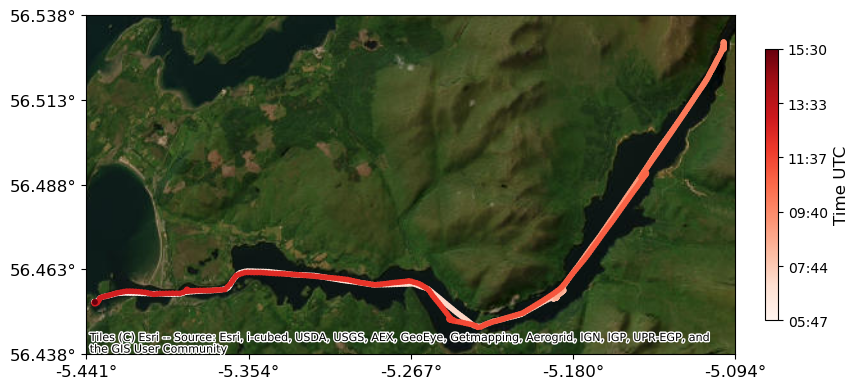

In [111]:
# Convert times to datetime (safe even if already datetime64)
times = pd.to_datetime(df["Date"])

# Convert to seconds since midnight
seconds = (
    times.dt.hour * 3600 +
    times.dt.minute * 60 +
    times.dt.second
)

# Define figure and axis
fig, (ax2) = plt.subplots(figsize=(15, 4))
ax2.set_ylim([ymin, ymax])
ax2.set_aspect(1)

# Scatter plot for station locations
im2 = ax2.scatter(
    x, y,
    c=seconds,
    s=10,
    linewidths=1,
    label="Time",
    marker='o',
    cmap='Reds'
)

# Add basemap
ctx.add_basemap(ax2, source=ctx.providers.Esri.WorldImagery)

# Manually reset limits after adding basemap
ax2.set_xlim([xmin, xmax])
ax2.set_ylim([ymin, ymax])

# Adjust plot settings
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

# Set custom tick locations
num_ticks = 5
ax2.set_xticks(np.linspace(ax2.get_xlim()[0], ax2.get_xlim()[1], num_ticks))
ax2.set_yticks(np.linspace(ax2.get_ylim()[0], ax2.get_ylim()[1], num_ticks))

# Longitude / Latitude formatting
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(merc_to_lonlat))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(merc_to_latlon))

# Add colorbar
cbar = plt.colorbar(
    im2,
    ax=ax2,
    orientation="vertical",
    shrink=0.8,
    pad=0.02
)

# Format colorbar ticks as HH:MM
cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos:
        f"{int(x//3600):02d}:{int((x%3600)//60):02d}"
    )
)

# Optional: set a fixed number of time ticks
ticks = np.linspace(seconds.min(), seconds.max(), 6)
cbar.set_ticks(ticks)

cbar.set_label("Time UTC", fontsize=12)

# Make layout nice
plt.tight_layout()

# Save figure
# fig.savefig('Time_map.png', format='png', dpi=300)

plt.show()